# Vector-field approximation with planted fixed points — Model_1_QR


In [8]:
# ==== Imports & global settings ====
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import library9 as lib

torch.set_default_dtype(torch.float32)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ==== Domain ====
XMIN, XMAX = -1.0, 4.0
YMIN, YMAX = -1.0, 4.0

# Quiver grid (for vector field plots)
QUIVER_RES = 30

# Heatmap grid (for error map)
HEATMAP_RES = 200



N_VISIBLE   = 2                           # 2D
M_HIDDEN    = 256                         # increase to test expressivity

# ODE integrator settings (not used in regression directly, but required by model init)
DT    = 0.03
STEPS = 60

# ==== Training hyperparams ====
N_TRAIN = 1_000_000
BATCH_SIZE = 500
EPOCHS = 200
LR = 1e-3

# Optional: rank stabilizer (QR supports it; keep 0 unless needed)
RANK_STAB_LAMBDA = 0.0
RANK_STAB_EPS    = 1e-6

device: cuda:1


In [9]:
# ==== 1) Define your base vector field F_base(x) here ====

FIXED_POINTS = torch.tensor([[0.0, 0.0], [0.0, 2.0], [3.0, 0.0], [1.0, 1.0] ], dtype=torch.float32, device=device)
NUM_CLASSES = FIXED_POINTS.shape[0]

LAMBDA = -0.6   # <0 gives one stable focus and one unstable focus
OMEGA  =  2.0   # rotation strength (increase for more “rotor”)

def F_base(x: torch.Tensor) -> torch.Tensor:
    X = x[..., 0]
    Y = x[..., 1]
    dX = X*(3-X) - 2*X*Y
    dY = Y*(2-Y) - X*Y
    return torch.stack([dX, dY], dim=-1)

with torch.no_grad():
    print("Valore del campo nei punti fissi dove si andrà a piantare (check per vedere se sono zero) =\n", F_base(FIXED_POINTS).detach().cpu().numpy())

Valore del campo nei punti fissi dove si andrà a piantare (check per vedere se sono zero) =
 [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


In [10]:
# ==== Plot helper (paper style): streamplot + attractors + consistent axes ====
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_field_paper(
    F_fn,
    title="",
    attractors=None,
    res=80,                 # good default for streamplot
    density=1.2,
    linewidth=1.0,
    arrowsize=1.1,
    figsize=(6, 6),
    savepath=None,
):
    xs = np.linspace(XMIN, XMAX, res)
    ys = np.linspace(YMIN, YMAX, res)
    Xg, Yg = np.meshgrid(xs, ys)
    pts = np.stack([Xg.ravel(), Yg.ravel()], axis=1)

    with torch.no_grad():
        v = F_fn(torch.tensor(pts, device=device, dtype=torch.float32)).detach().cpu().numpy()

    U = v[:, 0].reshape(res, res)
    V = v[:, 1].reshape(res, res)

    plt.figure(figsize=figsize)
    plt.streamplot(Xg, Yg, U, V, density=density, linewidth=linewidth, arrowsize=arrowsize)

    if attractors is not None:
        a = np.asarray(attractors)
        plt.scatter(a[:, 0], a[:, 1], s=120, marker="x", color="red")

    plt.xlim(XMIN, XMAX); plt.ylim(YMIN, YMAX)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.title(title)
    plt.grid(True, alpha=0.3)

    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")

    plt.show()


In [11]:
# ==== 2) Instantiate the model and inspect planted attractors (paper-style plot) ====
integrator = lib.EulerIntegrator(dt=DT, steps=STEPS)

model = lib.Model_1_QR(
    n_visible    = N_VISIBLE,
    m_hidden     = M_HIDDEN,
    num_classes  = NUM_CLASSES,

    non_linearity        = nn.Sigmoid(),
    hidden_non_linearity = nn.Identity(),

    # IMPORTANT: we pass the fixed points we want
    attractors = FIXED_POINTS,   # shape [C,2]
    attractor_value = 1.0,       # unused when attractors is provided

    integrator = integrator,
    qr_ridge   = 0.0,
).to(device)


x_attractors planted in the model (C x 2):
 [[0. 0.]
 [0. 2.]
 [3. 0.]
 [1. 1.]]


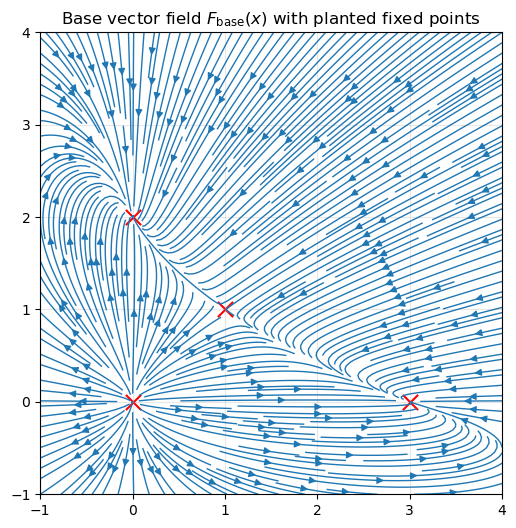

In [12]:

# attractors stored as [n_visible, C] -> convert to (C,2) numpy
x_attr = model.x_attractors.detach().T.cpu().numpy()
print("x_attractors planted in the model (C x 2):\n", x_attr)

# paper-style visualization
plot_field_paper(
    F_base,
    title=r"Base vector field $F_{\mathrm{base}}(x)$ with planted fixed points",
    attractors=x_attr,
    res=500,
    density=3,
    linewidth=1.0,
    arrowsize=1.0,
    figsize=(6, 6),
    savepath=None,   # e.g. "F_base_with_attractors.pdf"
)

In [13]:

# ==== 4) Create training dataset (uniform samples in [-2,2]^2) ====
def sample_uniform(n: int):
    x = torch.empty(n, 2).uniform_(XMIN, XMAX)
    x[:,1].uniform_(YMIN, YMAX)
    return x

X_train = sample_uniform(N_TRAIN)
with torch.no_grad():
    Y_train = F_base(X_train.to(device)).cpu()

train_ds = torch.utils.data.TensorDataset(X_train, Y_train)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print("Train batches:", len(train_loader))


Train batches: 2000


epoch    1 | loss=48.128910141 | fp_res=1.873e-05
epoch    2 | loss=6.399377870 | fp_res=5.519e-06
epoch    3 | loss=0.866413875 | fp_res=2.271e-05
epoch    4 | loss=0.177831024 | fp_res=2.456e-05
epoch    5 | loss=0.097675164 | fp_res=1.651e-05
epoch    6 | loss=0.029760222 | fp_res=1.544e-05
epoch    7 | loss=0.012789701 | fp_res=1.637e-05
epoch    8 | loss=0.007342772 | fp_res=2.546e-05
epoch    9 | loss=0.004284587 | fp_res=2.858e-05
epoch   10 | loss=0.002473476 | fp_res=5.492e-05
epoch   11 | loss=0.001302654 | fp_res=3.519e-05
epoch   12 | loss=0.000629348 | fp_res=1.362e-05
epoch   13 | loss=0.000339987 | fp_res=3.480e-05
epoch   14 | loss=0.000213485 | fp_res=5.286e-05
epoch   15 | loss=0.000143159 | fp_res=3.656e-05
epoch   16 | loss=0.000103050 | fp_res=1.718e-05
epoch   17 | loss=0.000081119 | fp_res=2.836e-05
epoch   18 | loss=0.000065227 | fp_res=3.070e-05
epoch   19 | loss=0.000056564 | fp_res=3.773e-05
epoch   20 | loss=0.000050052 | fp_res=3.274e-05
epoch   21 | loss=0

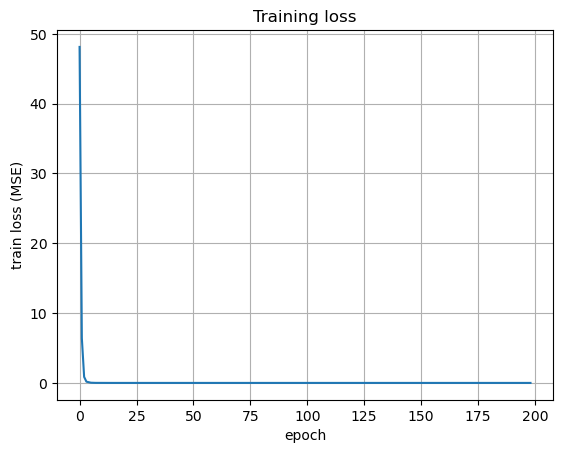

In [14]:

# ==== 5) Train: regress F_target with MSE loss ====
opt = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=1e-3)
losses = []

for epoch in range(1, EPOCHS):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        # Build A1/A2 once per batch (important for pseudoinverse/QR)
        A1 = model._A1_matrix()
        A2 = model._A2_matrix()
        b1 = model.b1
        b2 = model.b2
        f  = model.f
        f2 = model.f2

        pred = -xb + f(f2(xb) @ A2.T + b2) @ A1.T + b1  # [B,2]
        loss = torch.mean((pred - yb)**2)

        # optional rank stabilizer (only if available)
        if RANK_STAB_LAMBDA > 0.0 and hasattr(model, "_rank_stabilizer_logdet"):
            loss = loss + RANK_STAB_LAMBDA * model._rank_stabilizer_logdet(eps=RANK_STAB_EPS)

        opt.zero_grad()
        loss.backward()
        opt.step()

        running += float(loss.detach().cpu().item())

    epoch_loss = running / max(len(train_loader), 1)
    losses.append(epoch_loss)

    if epoch == 1 or epoch % 1 == 0:
        fp = None
        if hasattr(model, "max_fixed_point_residual"):
            with torch.no_grad():
                fp = float(model.max_fixed_point_residual())
        print(f"epoch {epoch:4d} | loss={epoch_loss:.9f}" + (f" | fp_res={fp:.3e}" if fp is not None else ""))

plt.figure()
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("train loss (MSE)")
plt.title("Training loss")
plt.grid(True)
plt.show()


In [15]:
# ==== Define learned vector field F_model (cached A1/A2 for fast evaluation) ====
import torch

@torch.no_grad()
def get_F_model_cached(model):
    model.eval()
    A1 = model._A1_matrix()
    A2 = model._A2_matrix()
    b1 = model.b1
    b2 = model.b2
    f  = model.f
    f2 = model.f2

    def F(x: torch.Tensor) -> torch.Tensor:
        return -x + f(f2(x) @ A2.T + b2) @ A1.T + b1
    return F

F_model = get_F_model_cached(model)  

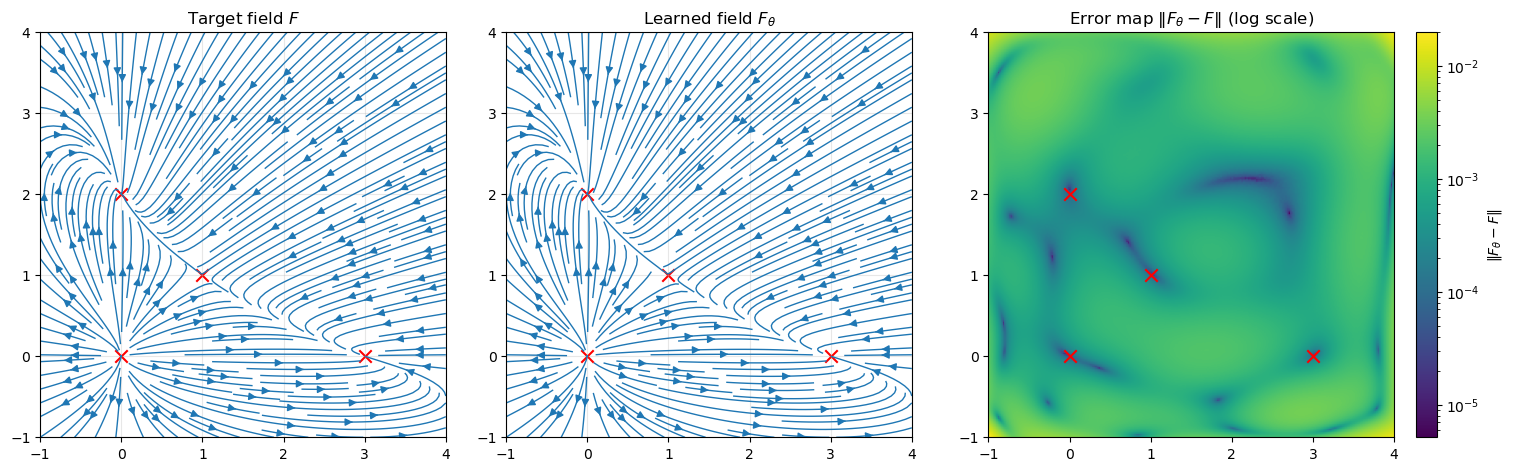

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def eval_on_grid(F, res):
    xs = np.linspace(XMIN, XMAX, res)
    ys = np.linspace(YMIN, YMAX, res)
    Xg, Yg = np.meshgrid(xs, ys)
    pts = np.stack([Xg.ravel(), Yg.ravel()], axis=1)
    v = F(torch.tensor(pts, device=device, dtype=torch.float32)).detach().cpu().numpy()
    U = v[:,0].reshape(res,res)
    V = v[:,1].reshape(res,res)
    speed = np.sqrt(U**2 + V**2)
    return Xg, Yg, U, V, speed

# Use same grid for target/learned for visual comparison
RES_VIZ = 80   # denser for streamplot than quiver
Xg, Yg, Ut, Vt, St = eval_on_grid(F_base, RES_VIZ)
_,  _, Um, Vm, Sm = eval_on_grid(F_model,  RES_VIZ)

# Error on a (possibly finer) grid
RES_ERR = 250
Xe, Ye, Ue_t, Ve_t, _ = eval_on_grid(F_base, RES_ERR)
_,  _, Ue_m, Ve_m, _ = eval_on_grid(F_model,  RES_ERR)
Err = np.sqrt((Ue_m-Ue_t)**2 + (Ve_m-Ve_t)**2)   # ||Fθ - F||

fig, ax = plt.subplots(1, 3, figsize=(15, 4.6), constrained_layout=True)

# (a) Target
ax[0].streamplot(Xg, Yg, Ut, Vt, density=2.0, linewidth=1.0, arrowsize=1.1)
ax[0].scatter(x_attr[:,0], x_attr[:,1], s=80, marker="x", color='red')
ax[0].set_title("Target field $F$"); ax[0].set_aspect("equal")
ax[0].set_xlim(XMIN, XMAX); ax[0].set_ylim(YMIN, YMAX); ax[0].grid(True, alpha=0.3)

# (b) Learned
ax[1].streamplot(Xg, Yg, Um, Vm, density=2.0, linewidth=1.0, arrowsize=1.1)
ax[1].scatter(x_attr[:,0], x_attr[:,1], s=80, marker="x", color='red')
ax[1].set_title("Learned field $F_\\theta$"); ax[1].set_aspect("equal")
ax[1].set_xlim(XMIN, XMAX); ax[1].set_ylim(YMIN, YMAX); ax[1].grid(True, alpha=0.3)

# (c) Error heatmap (log helps a lot)
im = ax[2].imshow(
    Err,
    origin="lower",
    extent=[XMIN, XMAX, YMIN, YMAX],
    aspect="equal",
    norm=LogNorm(vmin=max(Err.min(), 1e-6), vmax=Err.max())
)
ax[2].scatter(x_attr[:,0], x_attr[:,1], s=80, marker="x", color='red')
ax[2].set_title(r"Error map $\|F_\theta - F\|$ (log scale)")
ax[2].set_xlim(XMIN, XMAX); ax[2].set_ylim(YMIN, YMAX)

cbar = fig.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04)
cbar.set_label(r"$\|F_\theta - F\|$")

# Save paper-ready
plt.savefig("vectorfield_target_learned_error.pdf", bbox_inches="tight")
plt.show()